# CAPSTONE PROJECT ON EV SALES AND ADOPTION

**Kaggle Dataset Link:** https://www.kaggle.com/datasets/rameezmeerasahib/electric-vehicle-ev-sales-and-adoption?utm_source=chatgpt.com

In [ ]:
import pandas as pd
import zipfile

with zipfile.ZipFile('/content/archive (2).zip','r') as z:
    with z.open('train.csv') as f:
        df = pd.read_csv(f, parse_dates=['Date'])

df.head()

,Date,Region,Brand,Model,Vehicle_Type,Battery_Capacity_kWh,Discount_Percentage,Customer_Segment,Fast_Charging_Option,Units_Sold,Revenue
0,2023-07-01,Oceania,Toyota,i4,Crossover,62,6,High Income,No,260,3699780
1,2023-03-01,Oceania,Toyota,Leaf,Truck,70,19,High Income,Yes,347,7801424
2,2023-05-01,North America,Toyota,ID.5,Crossover,81,13,Middle Income,No,294,4813013
3,2023-02-01,Oceania,Tesla,Corolla EV,Truck,73,4,High Income,Yes,281,7484912
4,2023-10-01,North America,BYD,Leaf,Coupe,52,4,High Income,No,166,4025360


In [ ]:
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 531 entries, 0 to 530
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Date                  531 non-null    datetime64[ns]
 1   Region                531 non-null    object        
 2   Brand                 531 non-null    object        
 3   Model                 531 non-null    object        
 4   Vehicle_Type          531 non-null    object        
 5   Battery_Capacity_kWh  531 non-null    int64         
 6   Discount_Percentage   531 non-null    int64         
 7   Customer_Segment      531 non-null    object        
 8   Fast_Charging_Option  531 non-null    object        
 9   Units_Sold            531 non-null    int64         
 10  Revenue               531 non-null    int64         
dtypes: datetime64[ns](1), int64(4), object(6)
memory usage: 45.8+ KB


Index(['Date', 'Region', 'Brand', 'Model', 'Vehicle_Type',
       'Battery_Capacity_kWh', 'Discount_Percentage', 'Customer_Segment',
       'Fast_Charging_Option', 'Units_Sold', 'Revenue'],
      dtype='object')

In [ ]:
df.describe()

,Date,Battery_Capacity_kWh,Discount_Percentage,Units_Sold,Revenue
count,531,531.000000,531.000000,531.000000,5.310000e+02
mean,2023-06-09 06:25:05.084745984,69.408663,9.013183,227.881356,4.918762e+06
min,2023-01-01 00:00:00,40.000000,0.000000,50.000000,8.170320e+05
25%,2023-03-01 00:00:00,53.000000,3.000000,147.000000,2.944326e+06
50%,2023-06-01 00:00:00,70.000000,8.000000,234.000000,4.575344e+06
75%,2023-09-01 00:00:00,84.000000,14.000000,313.500000,6.469173e+06
max,2023-12-01 00:00:00,100.000000,20.000000,398.000000,3.016229e+07
std,NaN,17.627504,5.966085,97.905957,2.661565e+06


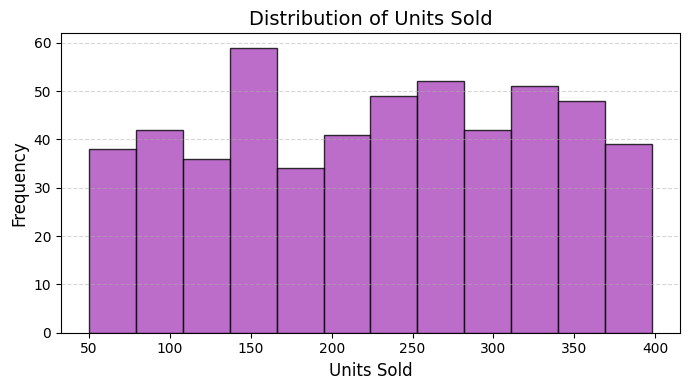

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.hist(df['Units_Sold'], bins=12, edgecolor='black', alpha=0.8, color='#AB47BC')
plt.title("Distribution of Units Sold", fontsize=14)
plt.xlabel("Units Sold", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

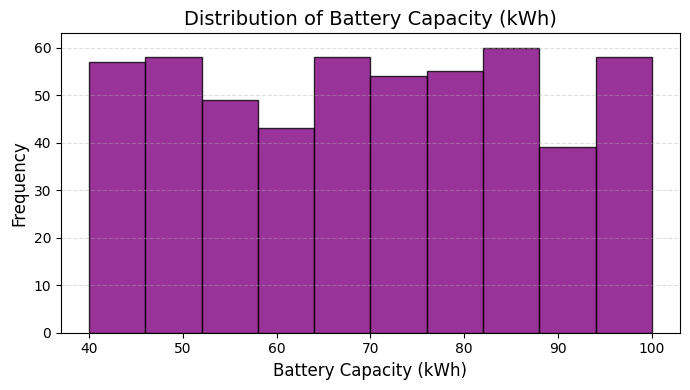

In [ ]:
plt.figure(figsize=(7,4))
plt.hist(df['Battery_Capacity_kWh'], bins=10, edgecolor='black', alpha=0.8, color='#800080')
plt.title("Distribution of Battery Capacity (kWh)", fontsize=14)
plt.xlabel("Battery Capacity (kWh)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

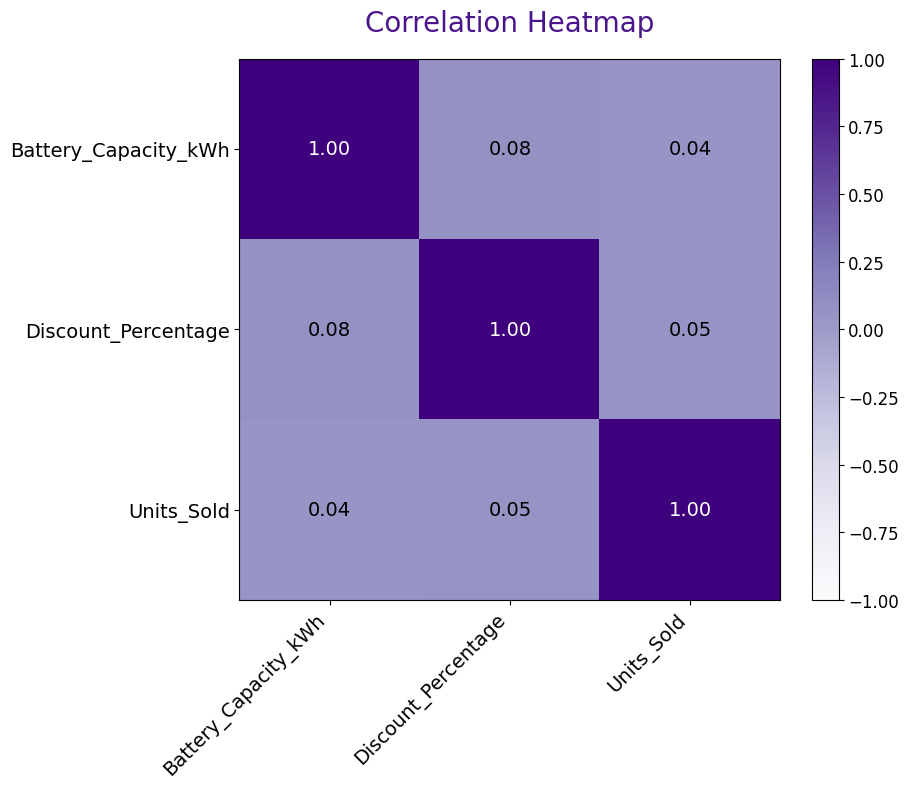

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

corr = df[['Battery_Capacity_kWh','Discount_Percentage','Units_Sold']].corr()

plt.figure(figsize=(10,8))
ax = plt.gca()

im = ax.imshow(corr, cmap='Purples', vmin=-1, vmax=1)

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=12)

ticks = np.arange(len(corr.columns))
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(corr.columns, fontsize=14, rotation=45, ha='right')
ax.set_yticklabels(corr.columns, fontsize=14)

ax.set_title("Correlation Heatmap", fontsize=20, color="#4A148C", pad=20)

for i in range(len(corr)):
    for j in range(len(corr)):
        val = corr.iloc[i, j]
        text_color = 'white' if val > 0.5 else 'black'
        ax.text(j, i, f"{val:.2f}", ha='center', va='center', color=text_color, fontsize=14)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

X = df[['Battery_Capacity_kWh','Discount_Percentage']]
y = df['Units_Sold']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("Intercept:", round(lr.intercept_, 3))
print("Coefficients:", lr.coef_)
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred)), 3))
print("R2 Score:", round(r2_score(y_test, y_pred), 3))

Intercept: 213.818
Coefficients: [0.10259268 0.98922827]
RMSE: 101.074
R2 Score: -0.005


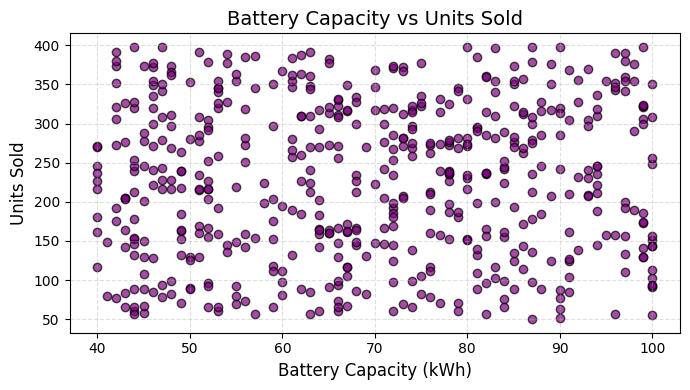

In [ ]:
plt.figure(figsize=(7,4))
plt.scatter(df['Battery_Capacity_kWh'], df['Units_Sold'],
            alpha=0.7, edgecolor='k', color='#800080')
plt.title("Battery Capacity vs Units Sold", fontsize=14)
plt.xlabel("Battery Capacity (kWh)", fontsize=12)
plt.ylabel("Units Sold", fontsize=12)
plt.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
import statsmodels.api as sm

X = df[['Battery_Capacity_kWh','Discount_Percentage']].copy()
y = df['Units_Sold'].copy()

mask = X.notna().all(axis=1) & y.notna()
X_clean = X[mask]
y_clean = y[mask]

X_clean = X_clean.astype(float)
y_clean = y_clean.astype(float)

X2 = sm.add_constant(X_clean)
ols_model = sm.OLS(y_clean, X2).fit()

print(ols_model.summary().tables[0])
print("\nCoefficients & p-values:")
print(ols_model.params.round(4))
print(ols_model.pvalues.round(4))

                            OLS Regression Results                            
Dep. Variable:             Units_Sold   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.151
Date:                Tue, 18 Nov 2025   Prob (F-statistic):              0.317
Time:                        12:52:17   Log-Likelihood:                -3185.9
No. Observations:                 531   AIC:                             6378.
Df Residuals:                     528   BIC:                             6391.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         

Coefficients & p-values:
const                   205.3945
Battery_Capacity_kWh      0.2172
Discount_Percentage       0.8223
dtype: float64
const                   0.0000
Battery_Capacity_kWh    0.3697
Discount

/tmp/ipython-input-2530781811.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df.set_index('Date').resample('M').sum()['Units_Sold']


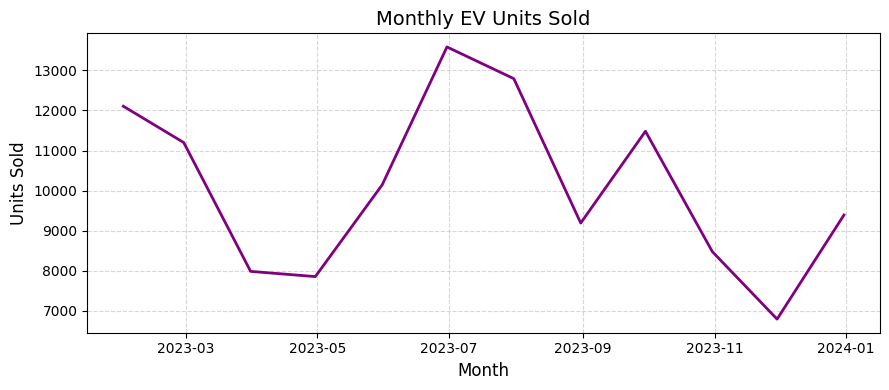

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
monthly = df.set_index('Date').resample('M').sum()['Units_Sold']

plt.figure(figsize=(9,4))
plt.plot(monthly, linewidth=2, color='#800080')
plt.title("Monthly EV Units Sold", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Units Sold", fontsize=12)
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
train = monthly[:-6]
test = monthly[-6:]

train.tail(), test

(Date
 2023-02-28    11200
 2023-03-31     7985
 2023-04-30     7855
 2023-05-31    10146
 2023-06-30    13585
 Freq: ME, Name: Units_Sold, dtype: int64,
 Date
 2023-07-31    12793
 2023-08-31     9191
 2023-09-30    11481
 2023-10-31     8477
 2023-11-30     6794
 2023-12-31     9392
 Freq: ME, Name: Units_Sold, dtype: int64)

In [ ]:
ma_val = train.rolling(3).mean().iloc[-1]
ma_forecast = [ma_val] * 6
ma_forecast

[np.float64(10528.666666666666),
 np.float64(10528.666666666666),
 np.float64(10528.666666666666),
 np.float64(10528.666666666666),
 np.float64(10528.666666666666),
 np.float64(10528.666666666666)]

In [ ]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

train = train.asfreq('M')

ses_model = SimpleExpSmoothing(train, initialization_method="estimated").fit()
ses_forecast_values = ses_model.forecast(len(test))

ses_forecast = pd.Series(ses_forecast_values, index=test.index)
ses_forecast

/tmp/ipython-input-207095462.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  train = train.asfreq('M')


,0
Date,
2023-07-31,13584.999949
2023-08-31,13584.999949
2023-09-30,13584.999949
2023-10-31,13584.999949
2023-11-30,13584.999949
2023-12-31,13584.999949


In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

train = train.asfreq('M')

holt_model = ExponentialSmoothing(train, trend='add', initialization_method="estimated").fit()
holt_forecast_values = holt_model.forecast(len(test))

holt_forecast = pd.Series(holt_forecast_values, index=test.index)
holt_forecast


/tmp/ipython-input-241224561.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  train = train.asfreq('M')


,0
Date,
2023-07-31,17023.999985
2023-08-31,20462.999987
2023-09-30,23901.999988
2023-10-31,27340.999990
2023-11-30,30779.999992
2023-12-31,34218.999994


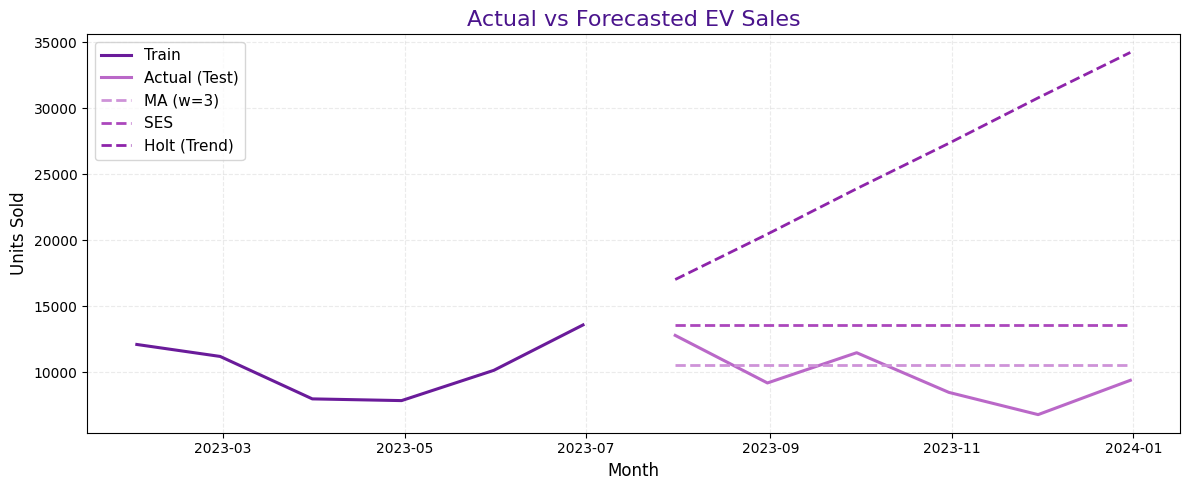

In [ ]:
import matplotlib.pyplot as plt

import pandas as pd
if not isinstance(ma_forecast, pd.Series):
    ma_forecast = pd.Series(ma_forecast, index=test.index)

plt.figure(figsize=(12,5))

plt.plot(train.index, train, label="Train", linewidth=2.2, color="#6A1B9A")
plt.plot(test.index, test, label="Actual (Test)", linewidth=2.2, color="#BA68C8")

plt.plot(ma_forecast.index, ma_forecast, label="MA (w=3)", linestyle='--', color="#CE93D8", linewidth=2)
plt.plot(ses_forecast.index, ses_forecast, label="SES", linestyle='--', color="#AB47BC", linewidth=2)
plt.plot(holt_forecast.index, holt_forecast, label="Holt (Trend)", linestyle='--', color="#8E24AA", linewidth=2)

plt.title("Actual vs Forecasted EV Sales", fontsize=16, color="#4A148C")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Units Sold", fontsize=12)
plt.legend(frameon=True, fontsize=11)
plt.grid(linestyle='--', alpha=0.25)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
def mape(true, pred): return np.mean(np.abs((true - pred) / true)) * 100
def rmse(true, pred): return np.sqrt(np.mean((true - pred)**2))

evals = {
    'MA': {'MAPE': mape(test.values, ma_forecast.values), 'RMSE': rmse(test.values, ma_forecast.values)},
    'SES': {'MAPE': mape(test.values, ses_forecast.values), 'RMSE': rmse(test.values, ses_forecast.values)},
    'Holt': {'MAPE': mape(test.values, holt_forecast.values), 'RMSE': rmse(test.values, holt_forecast.values)}
}
eval_df = pd.DataFrame(evals).T.round(2)
print(eval_df)

        MAPE      RMSE
MA     21.97   2132.00
SES    46.20   4361.80
Holt  183.97  17544.23
